
episode 1
------------------------------------------------------------
episode 1 total reward: -1485.6785 | steps taken: 500

episode 2
------------------------------------------------------------
episode 2 total reward: -543.0033 | steps taken: 244

episode 3
------------------------------------------------------------
episode 3 total reward: -518.5727 | steps taken: 213

episode 4
------------------------------------------------------------
episode 4 total reward: -714.1418 | steps taken: 341

episode 5
------------------------------------------------------------
episode 5 total reward: -752.7428 | steps taken: 375

episode 6
------------------------------------------------------------
episode 6 total reward: -695.2491 | steps taken: 318

episode 7
------------------------------------------------------------
episode 7 total reward: -956.2861 | steps taken: 478

episode 8
------------------------------------------------------------
episode 8 total reward: -1486.1102 | steps taken: 50

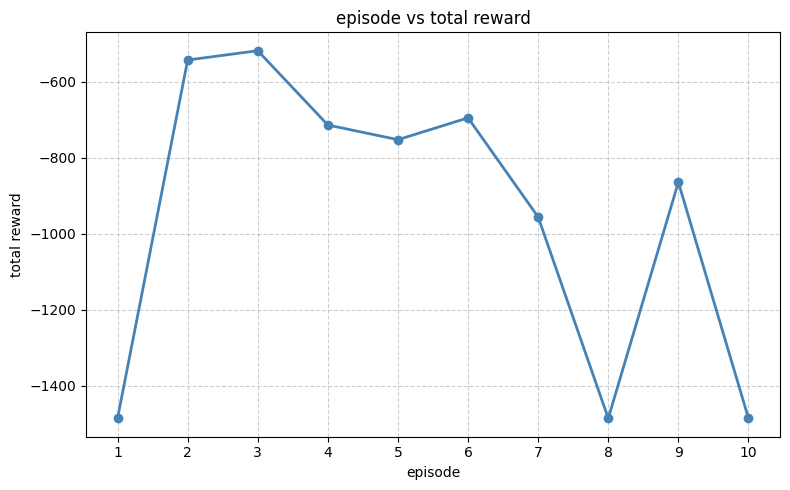

plot saved as acrobot_rewards.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# constants
g = 9.8
m1 = m2 = 1.0
l1 = l2 = 1.0
lc1 = lc2 = 0.5
I1 = I2 = 1.0
dt = 0.2
max_steps = 500
max_vel1 = 4 * np.pi
max_vel2 = 9 * np.pi

class AcrobotEnv:
    def __init__(self):
        self.state = None
        self.steps = 0

    def reset(self):
        self.state = np.random.uniform(-0.1, 0.1, size=4)
        self.steps = 0
        return self._get_obs()

    def _get_obs(self):
        theta1, theta2, dtheta1, dtheta2 = self.state
        return np.array([
            np.cos(theta1), np.sin(theta1),
            np.cos(theta2), np.sin(theta2),
            dtheta1, dtheta2
        ])

    def _compute_accel(self, theta1, theta2, dtheta1, dtheta2, torque):
        d1 = (m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * np.cos(theta2)) + I1 + I2)
        d2 = m2 * (lc2**2 + l1 * lc2 * np.cos(theta2)) + I2

        phi2 = m2 * lc2 * g * np.cos(theta1 + theta2 - np.pi / 2)
        phi1 = (
            -m2 * l1 * lc2 * dtheta2**2 * np.sin(theta2)
            - 2 * m2 * l1 * lc2 * dtheta2 * dtheta1 * np.sin(theta2)
            + (m1 * lc1 + m2 * l1) * g * np.cos(theta1 - np.pi / 2)
            + phi2
        )

        ddtheta2 = (torque + d2 / d1 * phi1 - m2 * l1 * lc2 * dtheta1**2 * np.sin(theta2) - phi2) / (
            m2 * lc2**2 + I2 - d2**2 / d1
        )
        ddtheta1 = -(d2 * ddtheta2 + phi1) / d1

        return ddtheta1, ddtheta2

    def step(self, action):
        torque_map = {0: -1.0, 1: 0.0, 2: 1.0}
        torque = torque_map[action]

        theta1, theta2, dtheta1, dtheta2 = self.state

        ddtheta1, ddtheta2 = self._compute_accel(theta1, theta2, dtheta1, dtheta2, torque)

        dtheta1_new = np.clip(dtheta1 + ddtheta1 * dt, -max_vel1, max_vel1)
        dtheta2_new = np.clip(dtheta2 + ddtheta2 * dt, -max_vel2, max_vel2)
        theta1_new = theta1 + dtheta1_new * dt
        theta2_new = theta2 + dtheta2_new * dt

        self.state = np.array([theta1_new, theta2_new, dtheta1_new, dtheta2_new])
        self.steps += 1

        height = -np.cos(theta1_new) - np.cos(theta1_new + theta2_new)
        reward = height - 1.0

        done = bool(height > 1.0) or self.steps >= max_steps

        return self._get_obs(), reward, done

    def simulate_action(self, action):
        torque_map = {0: -1.0, 1: 0.0, 2: 1.0}
        torque = torque_map[action]
        theta1, theta2, dtheta1, dtheta2 = self.state

        ddtheta1, ddtheta2 = self._compute_accel(theta1, theta2, dtheta1, dtheta2, torque)

        dtheta1_new = np.clip(dtheta1 + ddtheta1 * dt, -max_vel1, max_vel1)
        dtheta2_new = np.clip(dtheta2 + ddtheta2 * dt, -max_vel2, max_vel2)
        theta1_new = theta1 + dtheta1_new * dt
        theta2_new = theta2 + dtheta2_new * dt

        height = -np.cos(theta1_new) - np.cos(theta1_new + theta2_new)
        return height - 1.0


def greedy_policy(env):
    best_action = 0
    best_reward = -np.inf
    for a in range(3):
        r = env.simulate_action(a)
        if r > best_reward:
            best_reward = r
            best_action = a
    return best_action


# main loop
env = AcrobotEnv()
episode_rewards = []
torque_labels = {0: -1, 1: 0, 2: 1}

for ep in range(10):
    obs = env.reset()
    total_reward = 0
    done = False
    print(f"\nepisode {ep + 1}")
    print("-" * 60)

    while not done:
        action = greedy_policy(env)
        obs, reward, done = env.step(action)
        theta1, theta2, dtheta1, dtheta2 = env.state
        total_reward += reward

        # print(
        #     f"step {env.steps:3d} | torque: {torque_labels[action]:+d} | "
        #     f"theta1: {theta1:.4f} | theta2: {theta2:.4f} | "
        #     f"dtheta1: {dtheta1:.4f} | dtheta2: {dtheta2:.4f} | "
        #     f"reward: {reward:.4f}"
        # )

    episode_rewards.append(total_reward)
    print(f"episode {ep + 1} total reward: {total_reward:.4f} | steps taken: {env.steps}")

# summary
print("\n" + "=" * 60)
print("episode summary")
print("=" * 60)
for i, r in enumerate(episode_rewards):
    print(f"episode {i + 1}: total reward = {r:.4f}")

# plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), episode_rewards, marker='o', color='steelblue', linewidth=2, markersize=6)
plt.title("episode vs total reward")
plt.xlabel("episode")
plt.ylabel("total reward")
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("acrobot_rewards.png", dpi=150)
plt.show()
print("plot saved as acrobot_rewards.png")